# Initialize 

In [64]:
from pathlib import Path
import numpy as np
import yaml
import xarray as xr
import pymc as pm
import matplotlib.pyplot as plt
from pymc.model.transform.optimization import freeze_dims_and_data
import arviz as az
from tqdm.notebook import tqdm
import model_chain_inference as mci

In [65]:
plt.rcParams["figure.figsize"] = [12, 5]
%config InlineBackend.figure_format = 'retina'

# Experiment settings

In [66]:
experiment = "perf_1995_2025"
perspectives = ["prospective", "retrospective"]

RANDOM_SEED = 1234
n_samples = 1000
n_chains = 8

path = Path("../data")
model_specs_file = path / f"model_specs-{experiment}.yaml"

# Data prep

## Prepare inference datasets

An inference dataset prepares the data of a data scenario into a compact format that is ready for inference.

In [67]:
def get_inference_data(path, experiment, perspective, model):
    ids = xr.open_dataset(
        path / f"model_data-{experiment}-{perspective}-{model}.h5",
        decode_timedelta=False,
        engine="h5netcdf",
    )
    if "bernstein_basis" in ids.dims:
        ids = ids.set_xindex(["bernstein_degree", "bernstein_index"])
    return ids

In [68]:
def get_idata_path(path, experiment, perspective, model):
    return path / f"model_calibration-{experiment}-{perspective}-{model}.h5"

# Model definitions

In [69]:
settings_dsm = {
    "default": {
        "interpolation_dims": [
            "rmax",
            "sigma",
            "hs_exp",
            "hs_exp_alt",
            "M_plastic",
        ],
    },
}

In [70]:
settings_rate = {
    "default": {
        "mixing_dims": ["bernstein_index"],
        "theta0": {
            "dist": "Normal",
            "mu": -17.0,
            "sigma": 5.0,
        },
        "theta1": {
            "dist": "Exponential",
            "scale": 5.0,
            "dims": ["bernstein_index"],
        },
    },
}

In [71]:
settings_etas = {
    "default": None,
    "Kac": {
        "interpolation_dims": [
            "etas_d",
            "etas_q",
        ],
        "etas_c": {"dist": "LogNormal", "mu": 0.0, "sigma": 1.0},
        "etas_p": 1.35,
        "etas_K": {"dist": "Exponential", "scale": 0.1},
        "etas_a": {"dist": "Uniform", "lower": 0.0, "upper": 2.0},
    },
}

In [72]:
settings_size = {"default": None}

In [73]:
model_specs = {
    "ETS_bs4_etasKac": {
        "data_id": "ETS_bs",
        "etas_model_id": "Kac",
        "sel": {"thickness_origin": "grid", "bernstein_degree": 4},
    },
    "EVTS_bs4_etasKac": {
        "data_id": "EVTS_bs",
        "etas_model_id": "Kac",
        "sel": {"thickness_origin": "grid", "bernstein_degree": 4},
    },
    "ETS_rmax_etasKac": {
        "data_id": "ETS_rmax",
        "etas_model_id": "Kac",
        "sel": {"thickness_origin": "grid"},
    },
    "EVTS_rmax_etasKac": {
        "data_id": "EVTS_rmax",
        "etas_model_id": "Kac",
        "sel": {"thickness_origin": "grid"},
    },
}

In [74]:
with open(model_specs_file, "w") as f:
    yaml.dump(model_specs, f, default_flow_style=False)

In [75]:
model_collection = {}
attribute_collection = {}
for k, specs in tqdm(model_specs.items()):
    for perspective in perspectives:
        name = f"{experiment}-{perspective}-{k}"
        tqdm.write(f"creating model: {name}")

        sel = specs.get("sel", {})
        isel = specs.get("isel", {})
        data_id = specs["data_id"]

        rate_model_id = specs.get("rate_model_id", "default")
        size_model_id = specs.get("size_model_id", "default")
        dsm_model_id = specs.get("dsm_model_id", "default")
        etas_model_id = specs.get("etas_model_id", "default")

        # get concrete settings
        settings_local = {
            "rate_parameter_data": settings_rate[rate_model_id],
            "size_parameter_data": settings_size[size_model_id],
            "dsm_parameter_data": settings_dsm[dsm_model_id],
            "etas_parameter_data": settings_etas[etas_model_id],
        }

        # load data and store attributes for later use
        data_local = (
            get_inference_data(path, experiment, perspective, data_id)
            .sel(sel)
            .isel(isel)
        )
        attribute_collection[name] = dict(data_local.attrs)

        # generate model and test
        model_collection[name] = mci.generate_and_test_model(
            mci.generate_ts_etf_etas_model,
            data=data_local,
            settings=settings_local,
        )

  0%|          | 0/4 [00:00<?, ?it/s]

creating model: perf_1995_2025-prospective-ETS_bs4_etasKac
point={'theta0': array(-17.), 'theta1_log__': array([1.60943791, 1.60943791, 1.60943791, 1.60943791, 1.60943791]), 'etas_c_log__': array(0.49999997), 'etas_K_log__': array(-2.30258509), 'etas_a_interval__': array(0.), 'itp_sigma_interval__': array(0.), 'itp_hs_exp_interval__': array(0.), 'mix_bernstein_index_simplex__': array([0., 0., 0., 0.])}

point={'theta0': array(-17.), 'theta1_log__': array([1.60943791, 1.60943791, 1.60943791, 1.60943791, 1.60943791]), 'etas_c_log__': array(0.49999997), 'etas_K_log__': array(-2.30258509), 'etas_a_interval__': array(0.), 'itp_sigma_interval__': array(0.), 'itp_hs_exp_interval__': array(0.), 'mix_bernstein_index_simplex__': array([0., 0., 0., 0.])}

No problems found
creating model: perf_1995_2025-retrospective-ETS_bs4_etasKac
No problems found
creating model: perf_1995_2025-retrospective-ETS_bs4_etasKac
point={'theta0': array(-17.), 'theta1_log__': array([1.60943791, 1.60943791, 1.60943791

# Inference

In [76]:
result_collection = {}

In [77]:
for k, specs in tqdm(model_collection.items()):
    tqdm.write(f"\n{k}")
    # split k into scenario, perspective, model
    experiment, perspective, model = k.split("-")
    idata_path = get_idata_path(path, experiment, perspective, model)

    if k in result_collection:
        tqdm.write(f"model {k} already sampled - skipping")
        # idata = result_collection[k]
        # idata.attrs.update(attribute_collection[k])
        # result_collection[k] = idata
        # idata.to_netcdf(idata_path)
        continue

    frozen_model = freeze_dims_and_data(specs)
    with frozen_model:
        if len(specs.discrete_value_vars) == 0:
            nuts_sampler = "blackjax"
        else:
            nuts_sampler = "pymc"
        tqdm.write(f"nuts_sampler: {nuts_sampler}")
        if idata_path.exists():
            tqdm.write(f"file {idata_path.as_posix()} exists - remove to overwrite")
            idata = az.from_netcdf(idata_path).load()
            # idata.close()
            # idata_path.unlink()
        else:
            rng = np.random.default_rng(RANDOM_SEED)
            try:
                idata = pm.sample(
                    draws=n_samples,
                    chains=n_chains,
                    cores=n_chains,
                    target_accept=0.9,
                    idata_kwargs={"log_likelihood": True},
                    random_seed=rng,
                    nuts_sampler=nuts_sampler,
                )
                display(az.summary(idata))
                idata.attrs.update(attribute_collection[k])
                idata.to_netcdf(idata_path)
            except Exception as e:
                tqdm.write(f"error: {e}\n")

        result_collection[k] = idata

  0%|          | 0/8 [00:00<?, ?it/s]


perf_1995_2025-prospective-ETS_bs4_etasKac
nuts_sampler: blackjax
file ../data/model_calibration-perf_1995_2025-prospective-ETS_bs4_etasKac.h5 exists - remove to overwrite
nuts_sampler: blackjax
file ../data/model_calibration-perf_1995_2025-prospective-ETS_bs4_etasKac.h5 exists - remove to overwrite

perf_1995_2025-retrospective-ETS_bs4_etasKac

perf_1995_2025-retrospective-ETS_bs4_etasKac
nuts_sampler: blackjax
file ../data/model_calibration-perf_1995_2025-retrospective-ETS_bs4_etasKac.h5 exists - remove to overwrite
nuts_sampler: blackjax
file ../data/model_calibration-perf_1995_2025-retrospective-ETS_bs4_etasKac.h5 exists - remove to overwrite

perf_1995_2025-prospective-EVTS_bs4_etasKac

perf_1995_2025-prospective-EVTS_bs4_etasKac
nuts_sampler: blackjax
file ../data/model_calibration-perf_1995_2025-prospective-EVTS_bs4_etasKac.h5 exists - remove to overwrite
nuts_sampler: blackjax
file ../data/model_calibration-perf_1995_2025-prospective-EVTS_bs4_etasKac.h5 exists - remove to over

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
perf_1995_2025-retrospective-EVTS_bs4_etasKac,0,-10539.750466,9.278500,0.000000,5.544035e-01,25.342429,0.000000,False,log
perf_1995_2025-retrospective-ETS_bs4_etasKac,1,-10541.534385,9.363273,1.783919,4.455965e-01,26.090506,4.864902,False,log
perf_1995_2025-retrospective-EVTS_rmax_etasKac,2,-10544.589363,7.781102,4.838897,0.000000e+00,25.605288,3.033929,False,log
perf_1995_2025-retrospective-ETS_rmax_etasKac,3,-10544.726341,7.442910,4.975875,6.661338e-16,26.296648,4.328205,False,log


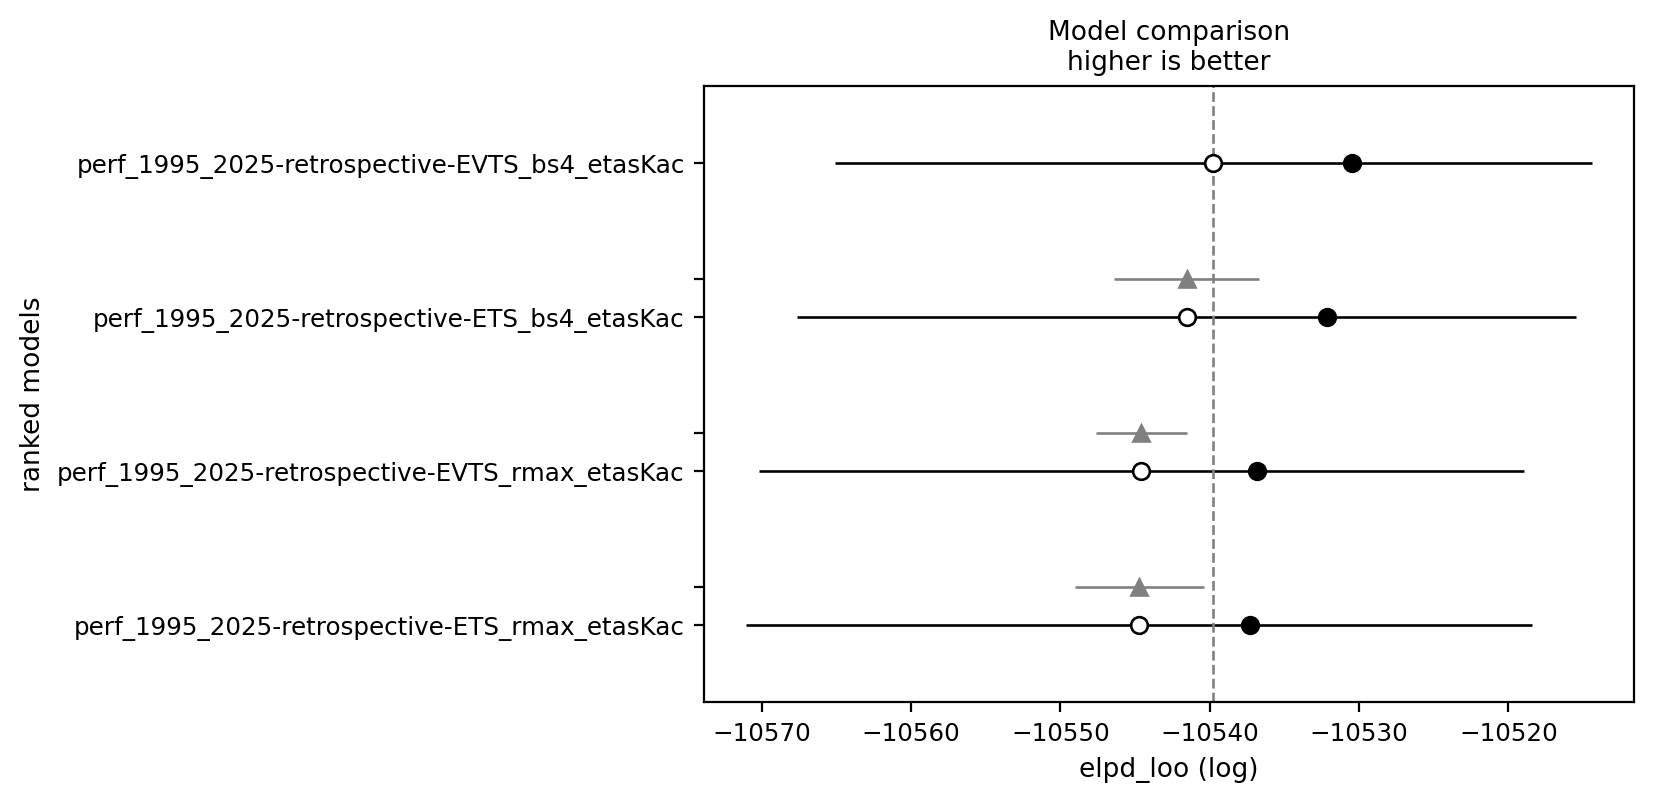

In [78]:
azc = az.compare(
    {k: v for k, v in result_collection.items() if "retrospective" in k},
    ic="loo",
    var_name="XT",
)
az.plot_compare(azc, insample_dev=True, plot_ic_diff=True)
azc